# Computation of shape during growth of propagules (2)


##  Documentation and Imports


Created on 27-05-2021 (Adapted from ShapeComputation.ipynb)

Author: Valentin Laplaud

This code aims to compute the shape of propagules growing in microfluidic chips. It detects gemmae contours using binarization, and saves the data of the contour position on the image, as well as the quality of image focus and the position of the center of the gemma on the image.

In [1]:
# plotting stuff
import matplotlib as mpl
mpl.use('TkAgg')
%matplotlib inline
import matplotlib.pyplot as plt
from cycler import cycler
#Default colors
colorcycle = [plt.get_cmap('gist_rainbow')(1. * i/30) for i in range(30)]
mpl.rcParams['axes.prop_cycle'] = cycler(color=colorcycle)

# numbers handling
import numpy as np
import pandas as pd

# signal processing 
from scipy.signal import savgol_filter, correlate, correlation_lags
from scipy.interpolate import interp1d

# images handling
from skimage import io
from skimage.filters import threshold_otsu, gaussian, laplace, sobel
from skimage.measure import label, regionprops, regionprops_table
from skimage.util import invert
from skimage.morphology import binary_opening, binary_closing, remove_small_holes,binary_erosion
from skimage.color import rgb2gray
from skimage.segmentation import active_contour, morphological_geodesic_active_contour,morphological_chan_vese, checkerboard_level_set, inverse_gaussian_gradient
import cv2 as cv

# to hide known warnings
import warnings

# General system functions
import os
import shutil
import sys

import time

# my functions
sys.path.append('../')
import VallapFunc as vf


##  Define contour computation functions



###  Image binarization

Binarize the image to get a large mask that will be used as a starting point for active contour algorithm

GetHue : Computes Hue from RGB image. Also applies a gaussian blur for smoothness.

Binarize : Threshold the Hue image using the Otsu threshold. Then opens the image using a circle of 100 µm.

create_circular_mask : create the circle for opening

In [2]:
def GetHue(RGBimg, **kwargs):

    #init and read kwargs
    DebugPlots = False
    
    for key, value in kwargs.items(): 
        if key == 'debug':
            DebugPlots = value
        else:
            print('Unknown key : ' + key + '. Kwarg ignored.')
    
    warnings.filterwarnings("ignore")   

    HueImg = np.zeros(RGBimg.shape[0:2]) # initialize Hue img

    Maxes = RGBimg.argmax(axis=2)
    Mines = RGBimg.argmin(axis=2)

    # when red is max
    mask = Maxes == 0
    HueImg[mask] = (RGBimg[mask,1]-RGBimg[mask,2])/(RGBimg[mask,:].max(axis=1)-RGBimg[mask,:].min(axis=1))

    # when green is max
    mask = Maxes == 1
    HueImg[mask] = 2 + (RGBimg[mask,2]-RGBimg[mask,0])/(RGBimg[mask,:].max(axis=1)-RGBimg[mask,:].min(axis=1))

    # when blue is max
    mask = Maxes == 2
    HueImg[mask] = 4 + (RGBimg[mask,0]-RGBimg[mask,1])/(RGBimg[mask,:].max(axis=1)-RGBimg[mask,:].min(axis=1))


    # correct for nans
    HueImg[np.isnan(HueImg)] = 5

    HueImg = (HueImg/6)%1
          
    if DebugPlots:
                
        fig, (ax0, ax1) = plt.subplots(ncols=2, dpi=200)
        
        fig.suptitle('Debug plots for "GetHue" function :')
        ax0.imshow(RGBimg)
        ax0.set_title("RGB image")
        ax0.axis('off')
        ax1.imshow(HueImg, cmap='gray')
        ax1.set_title("Hue image")
        ax1.axis('off')
        
        plt.show()
        
        print('')
    
    return(HueImg)

def Binarize(Img, Scale, **kwargs):

    #init and read kwargs
    DebugPlots = False
    
    for key, value in kwargs.items(): 
        if key == 'debug':
            DebugPlots = value
        else:
            print('Unknown key : ' + key + '. Kwarg ignored.')
    
    BWimg = invert(Img > threshold_otsu(Img)) # apply threshold 
    
    # to avoid filling up to the edges
    BWimg[0:9,0:] = 0    
    BWimg[0:,0:9] = 0 
    BWimg[0:,BWimg.shape[1]-10:BWimg.shape[1]]= 0
    BWimg[BWimg.shape[0]-10:BWimg.shape[0],0:] = 0
    
    FilledBWimg = remove_small_holes(BWimg, area_threshold=1e5) # fills dark regions
    
    Size = np.round(100*Scale) # 100µm in pixels
    
    selem = create_circular_mask(Size,Size) # create circular element for opening

    FinalImg = binary_opening(FilledBWimg,selem) # image opening
    
    if DebugPlots:        
       
        fig, [[ax0, ax1], [ax2, ax3]] = plt.subplots(nrows = 2, ncols=2,dpi = 200)    
        fig.suptitle('Debug plots for "Binarize" function :')
        ax0.imshow(Img, cmap='gray')
        ax0.set_title("Original image")
        ax0.axis('off')
        ax1.imshow(BWimg, cmap='gray')
        ax1.set_title("Thresholded image")
        ax1.axis('off')
        ax2.imshow(FilledBWimg, cmap='gray')
        ax2.set_title("Filled image")
        ax2.axis('off') 
        ax3.imshow(FinalImg, cmap='gray')
        ax3.set_title("Opened image")
        ax3.axis('off')        
        
        plt.show()
        
        print('')
    
    return(FinalImg)

def create_circular_mask(h, w, center=None, radius=None):

    if center is None: # use the middle of the image
        center = (int(w/2), int(h/2))
    if radius is None: # use the smallest distance between the center and image walls
        radius = min(center[0], center[1], w-center[0], h-center[1])

    Y, X = np.ogrid[:h, :w]
    dist_from_center = np.sqrt((X - center[0])**2 + (Y-center[1])**2)

    mask = dist_from_center <= radius
    return mask

### Edge detection from the binary image

Returns the edge positions dnterd around the origin, in cartesian and circular corrdinate. Also returns position of the center in the original image and the area of the propagule

In [3]:
def getEdgeAndArea(BinImg,Scale):
    
    # Find largest contour 
    cnts, _ = cv.findContours(BinImg, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
    cnt = max(cnts, key=cv.contourArea)
    
    Area = cv.contourArea(cnt)*Scale**2

    # Create image with only largest object
    out = np.zeros(BinImg.shape, np.uint8)
    cv.drawContours(out, [cnt], -1, 255, cv.FILLED)
    BinImg = cv.bitwise_and(BinImg, out)

    # Detecting edges and computing their position
    edge = sobel(BinImg)>threshold_otsu(sobel(BinImg))
    indices = np.where(edge != [0])
    
    # Computing center of propagule using euclidian distance transform
    dist = cv.distanceTransform(BinImg, cv.DIST_L2, 3)
    regions = regionprops(BinImg,dist)
    center = regions[0].weighted_centroid
    
    # Edge coorinate relative to the center
    relativeIndicesX = indices[0]-center[0]
    relativeIndicesY = indices[1]-center[1]
    
    # Edge coordinate in circular system
    Theta,Radius = vf.ToCirc(relativeIndicesX,relativeIndicesY, angle = 'deg')

    # Sorting coordinate based on angle
    FullCoordinates = np.stack((Theta,Radius,relativeIndicesX,relativeIndicesY),axis=1)
    SortedCoord = FullCoordinates[FullCoordinates[:,0].argsort(),]
    
    SortedTheta = SortedCoord[:,0]
    SortedRadius = SortedCoord[:,1]
    #SortedEdgeX = SortedCoord[:,2]
    #SortedEdgeY = SortedCoord[:,3]
    
    return(SortedTheta,SortedRadius,center,Area)

##  Main functions
   

### Image Binarization

In [4]:
def BinarizeImage(StackList, P, Scale, **kwargs):

    #init and read kwargs
    DebugPlots = False
    
    for key, value in kwargs.items(): 
        if key == 'debug':
            DebugPlots = value
        else:
            print('Unknown key : ' + key + '. Kwarg ignored.')
    
    for s in StackList:

        print('Processing ' + s + ' :')    

        RGBstack = io.imread(P + '\\' + s + '.tif') # get the tiff stack

        # Savefolders for Hue and Binary stacks
        if not os.path.exists(P + '\\Processed'):
            os.mkdir(P + '\\Processed') # create global folder        
        
        if not os.path.exists(P + '\\Processed\\' + s + '_Hue'):
            # shutil.rmtree(P + '\\' + s + '_Hue') # remove folder and contents
            os.mkdir(P + '\\Processed\\' + s + '_Hue') # create hue image folder
            isHue = False
        else:
            isHue = True

        if not os.path.exists(P + '\\Processed\\' + s + '_Binarized'):
            # shutil.rmtree(P + '\\' + s + '_Binarized') # remove folder and contents
            os.mkdir(P + '\\Processed\\' + s + '_Binarized') # create binarize image folder
            isBin = False
        else:
            isBin = True


        # pre-process images
        for i in range(len(RGBstack)):
          
            # Hue channel computation
            if not isHue:
                print('Computing Hue for image ' + str(i+1) + '/' + str(len(RGBstack)).ljust(10), flush=True, end = '\r')
                HueImg = GetHue(gaussian(RGBstack[i],1,multichannel=True),debug =DebugPlots) 
                io.imsave(P + '\\Processed\\' + s + '_Hue\\' + str(i) + '.tif', np.uint8(HueImg*255), plugin='tifffile')

            else:
                if os.path.exists(P + '\\Processed\\' + s + '_Hue\\' + str(i) + '.tif'):
                    
                    HueImg = io.imread(P + '\\Processed\\' + s + '_Hue\\' + str(i) + '.tif')
                    
                else:
                    print('Computing Hue for image ' + str(i+1) + '/' + str(len(RGBstack)).ljust(10), flush=True, end = '\r')
                    HueImg = GetHue(gaussian(RGBstack[i],1,multichannel=True),debug =DebugPlots) 
                    io.imsave(P + '\\Processed\\' + s + '_Hue\\' + str(i) + '.tif', np.uint8(HueImg*255), plugin='tifffile')

            # Binarization      
            if not isBin:
                print('Binarization of image ' + str(i+1) + '/' + str(len(RGBstack)).ljust(15), flush=True, end = '\r')
                BinImg = Binarize(gaussian(HueImg,5),Scale,debug =DebugPlots)
                io.imsave(P + '\\Processed\\' + s + '_Binarized\\' + str(i) + '.tif', np.uint8(BinImg*255), plugin='tifffile')
            
            else:
                if os.path.exists(P + '\\Processed\\' + s + '_Binarized\\' + str(i) + '.tif'):
                    BinImg = io.imread(P + '\\Processed\\' + s + '_Binarized\\' + str(i) + '.tif')  
                else:
                    print('Binarization of image ' + str(i+1) + '/' + str(len(RGBstack)).ljust(15), flush=True, end = '\r')
                    BinImg = Binarize(gaussian(HueImg,5),Scale,debug =DebugPlots)
                    io.imsave(P + '\\Processed\\' + s + '_Binarized\\' + str(i) + '.tif', np.uint8(BinImg*255), plugin='tifffile')
            

    
        print('Binarization done for ' + str(len(RGBstack)) + '/' + str(len(RGBstack)) + ' images'.ljust(20), flush=True)

        
    return

### Contour detection

In [5]:
def GetContours(StackList,P, Scale, date, **kwargs):
      
    # init and read kwargs    
    DebugPlots = False
    
    for key, value in kwargs.items(): 
        if key == 'debug':
            DebugPlots = value
        else:
            print('Unknown key : ' + key + '. Kwarg ignored.')
    
    # initialize dataframme
    GD = pd.DataFrame(data=None,columns=['Img','Time (min)','FocusValue','GoodFocus','Area','Xcenter','Ycenter']) 

    CD = pd.DataFrame(data=None,columns=['Img','Ximg','Yimg','GoodFocus']) 

    
    for s in StackList:

        print('Processing ' + s + ' :')   
        
        # Loading video
        RGBstack = io.imread(P + '\\' + s + '.tif') # get the tiff stack
        
        n = len(RGBstack)
               
        # Evaluating focus quality
        for i in range(n):
            
            print('Checking focus for image ' + str(i+1) + '/' + str(len(RGBstack)).ljust(10), flush=True, end = '\r')
                    
            FocusValue = np.sum(np.absolute(laplace(np.max(RGBstack[i],2))))
            
            GD = GD.append(pd.DataFrame(data = [[i, i/FPH*60, FocusValue]], index = [s], columns = ['Img','Time (min)','FocusValue']))
            
        
        GoodFocusList = np.argwhere(np.concatenate(([0],np.diff(GD.at[s,'FocusValue'])))/GD.at[s,'FocusValue'].median()>-0.05)

        GD.at[s, 'GoodFocus'] = GD.loc[s].apply(
        lambda row: np.isin(row['Img'],GoodFocusList) , axis = 1)

        print('Focus checked.'.ljust(35), flush = True)        
        
        jet_colorcycle = [plt.get_cmap('jet')(1. * i/n) for i in range(n)]
        mpl.rcParams['axes.prop_cycle'] = cycler(color=jet_colorcycle)        


        for i in range(n):
            
            print('Measuring contour for image ' + str(i+1) + '/' + str(len(RGBstack)).ljust(10), flush=True, end = '\r')
                        
            # Loading binary image
            BinImg = io.imread(P + '\\Processed\\' + s + '_Binarized\\' + str(i) + '.tif')

            # Computing propagule edge and area from binary image
            Theta,Radius,center,Area = getEdgeAndArea(BinImg,Scale)  

            # Saving area and propagul center
            GD.loc[(GD.index == s) & (GD['Img'] == i) ,'Area'] = Area  
            GD.loc[(GD.index == s) & (GD['Img'] == i) ,'Xcenter'] = center[1] 
            GD.loc[(GD.index == s) & (GD['Img'] == i) ,'Ycenter'] = center[0]    

            # interpolation of contour on regular grid
            extraR = Radius[np.argmin(np.abs(Theta-180))]   
            f = interp1d(Theta, Radius, fill_value=(extraR,extraR),bounds_error=False)
            Thetanew = np.linspace(-179.5,180,720,endpoint=True)
            Radiusnew = f(Thetanew)  

            # Smoothing
            SmoothRadius = savgol_filter(Radiusnew,7,3)  
                
            SmoothX,SmoothY = vf.ToCart(Thetanew, SmoothRadius, angle='deg')
            
            # Storing contour data
            data = {'Ximg':SmoothY+center[1],
                        'Yimg':SmoothX+center[0],  
                        'Img':i*np.ones(len(SmoothX)),
                        'GoodFocus':np.repeat(GD.loc[(GD.index == s) &
                                                             (GD['Img'] == i) ,'GoodFocus'],len(SmoothX))} 

            CD = CD.append(pd.DataFrame(data=data,index = np.repeat(s,len(SmoothX))) ) # adding to global dataframe
            
            if i == 1:
                RGBimg = io.imread(P + '\\' + s + '.tif', key = 1)

                plt.figure(dpi=250,facecolor='white')
                plt.title(s)
                plt.imshow(RGBimg)
                plt.plot(SmoothY+center[1],SmoothX+center[0],'c')
            
        print('Contours saved.'.ljust(35), flush = True)
         
    return(CD,GD)

## 4. Enter data and run



### 4.1 Data details

In [6]:
Scale1 = 0.4 # Spatial scale (µm/px) 16-02-2021

Scale2 = 2.27 # Spatial scale (µm/px) 18-03-2021

Scale3 = 1.72 # Spatial scale (µm/px) 19-03-2021

FPH = 2 # Frames per hour

# Paths to data
P1 = r'd:\Users\laplaud\Desktop\PostDoc\Data\Microflu\Manips\2021.02.16'

P2 = r'd:\Users\laplaud\Desktop\PostDoc\Data\Microflu\Manips\2021.03.18'

P3 = r'd:\Users\laplaud\Desktop\PostDoc\Data\Microflu\Manips\2021.03.19'


# List of stacks to analyse

# experiment of 16-02-2021
# outside traps
StackListFree210216 = ['Propagule-03','Propagule-09','Propagule-12','Propagule-18','Propagule-19',
                'Propagule-24','Propagule-25']

# inside traps
StackListTrapped210216 = ['Propagule-04','Propagule-06','Propagule-07','Propagule-08',
                    'Propagule-13','Propagule-14','Propagule-15','Propagule-16','Propagule-17',
                    'Propagule-20','Propagule-21','Propagule-22','Propagule-23','Propagule-26',
                    'Propagule-27','Propagule-28','Propagule-29','Propagule-30']


# experiments of 18-03-2021
StackList210318 = ['PPG1','PPG2','PPG3','PPG4','PPG6','PPG7','PPG9','PPG10','PPG11',
                   'PPG12','PPG13','PPG14','PPG15','PPG16','PPG17','PPG18','PPG19','PPG20','PPG21',
                   'PPG22','PPG23','PPG24','PPG25','PPG26','PPG27','PPG28','PPG29']

            # No Rhizoid
StackList210318 = ['PPG2','PPG3','PPG6','PPG7','PPG9','PPG10','PPG11',
                   'PPG14','PPG15','PPG16','PPG18','PPG19',
                   'PPG22','PPG23','PPG24','PPG25','PPG26','PPG27','PPG28','PPG29']           


StackList210318 = ['PPG7'] # Tests



# experiments of 19-03-2021 (68h, cropped when air arrives, at least 52 images)
StackList210319 = ['PPG1','PPG2','PPG6','PPG8','PPG9','PPG10','PPG11',
                   'PPG12','PPG13','PPG14','PPG15','PPG16','PPG17','PPG18','PPG19','PPG20','PPG21',
                   'PPG22']

StackList210319 = ['PPG19'] # Tests


### Run

In [7]:
## Image Binarization
BinarizeImage(StackList210318, P2, Scale2, debug = False)
BinarizeImage(StackList210319, P3, Scale3, debug = False)

Processing PPG7 :
Binarization done for 49/49 images             
Processing PPG19 :
Binarization done for 116/116 images             


Processing PPG7 :
Focus checked.                        
Contours saved.                          
Processing PPG19 :
Focus checked.                         
Contours saved.                           


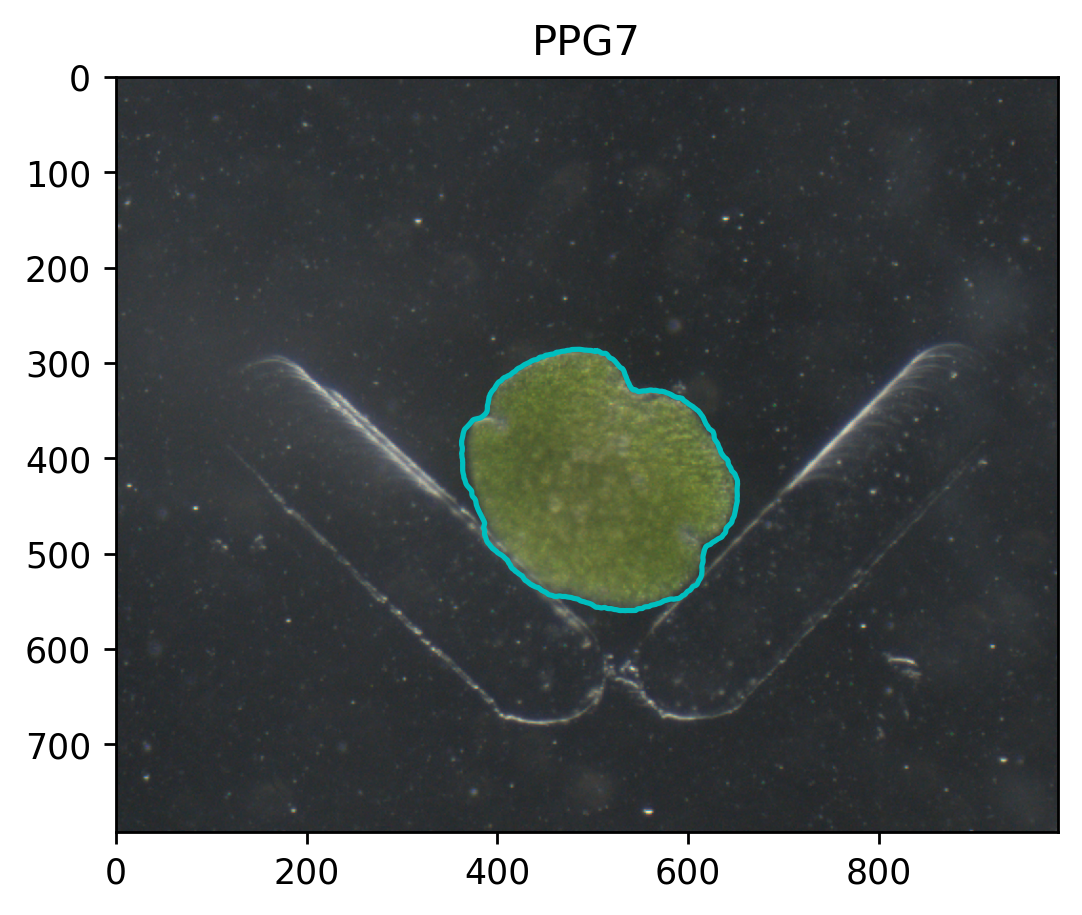

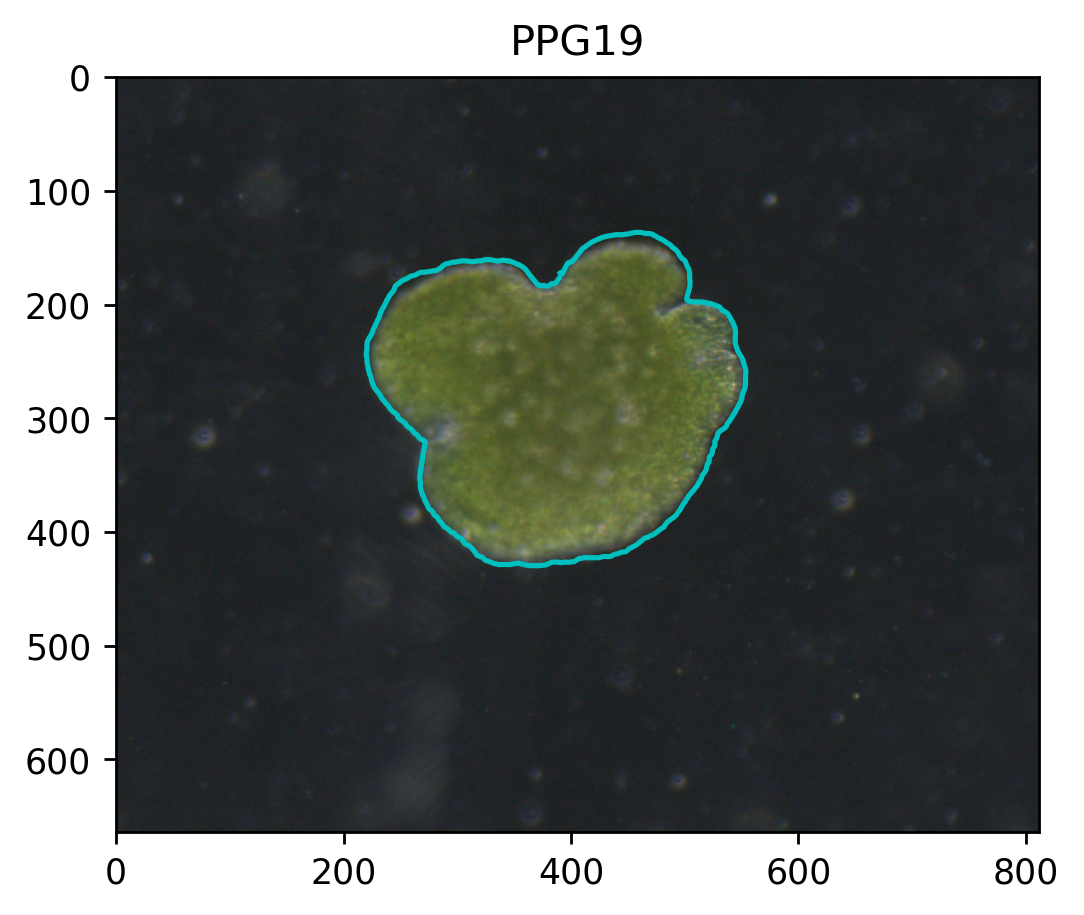

In [8]:
## Contour computation

ContourData210318,GlobalData210318 = GetContours(StackList210318,P2, Scale2,'180321', debug=False)

ContourData210319, GlobalData210319 = GetContours(StackList210319,P3, Scale3, '190321', debug=False)


In [9]:
## Saving
GlobalData210318.to_csv(P2 + '\\GlobalData210318_Img.csv',index_label = 'Ind')
ContourData210318.to_csv(P2 + '\\ContourData210318_Img.csv',index_label = 'Ind')

GlobalData210319.to_csv(P3 + '\\GlobalData210319_Img.csv',index_label = 'Ind')
ContourData210319.to_csv(P3 + '\\ContourData210319_Img.csv',index_label = 'Ind')

# Test Zone